# AFOLU: a third carbon removal pathway?

**Background:** Net-zero CO2 = fossil/industry emissions offset by removals. Removals can come
from (1) **CCS** (geological storage, including BECCS) or (2) **AFOLU sinks** (reforestation,
soil carbon, land-use change). Our outcome definition penalises high CCS — but what about
AFOLU-led removal strategies? Are there desired-success scenarios reaching net-zero primarily
through land-sector sinks rather than engineered CCS?

**This notebook:**
1. Maps scenarios in (Cumulative CCS, AFOLU CO2 at 2070) space by outcome
2. Identifies AFOLU-led removal strategies among desired-success pathways
3. Tests whether AFOLU CO2 is a significant differentiator between desired and CCS-reliant pathways
4. Shows the AFOLU trajectory over time across outcome groups

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')

data = pd.read_csv('../antoine_folder/data_for_scenariodiscovery_full.csv')

CAT_DESIRED  = 'Desired (NZ + low CCS)'
CAT_HIGHCCS  = 'NZ but CCS-reliant'
CAT_FAILURE  = 'Failure'
COLORS = {CAT_DESIRED: '#2ca02c', CAT_HIGHCCS: '#ff7f0e', CAT_FAILURE: '#9ecae1'}
ORDER  = [CAT_FAILURE, CAT_HIGHCCS, CAT_DESIRED]

data['category'] = CAT_FAILURE
data.loc[data['success_nz2070'] & ~data['low_ccs_reliance'], 'category'] = CAT_HIGHCCS
data.loc[data['desired_success'], 'category'] = CAT_DESIRED

CCS_CUM_COL  = 'Emissions Diagnostics|Cumulative CCS [2020-2100, Gt CO2]'
AFOLU_COL_70 = 'Emissions|CO2|AFOLU|2070'
AFOLU_COL_50 = 'Emissions|CO2|AFOLU|2050'

# Convert AFOLU to GtCO2 (data is in MtCO2)
for c in [AFOLU_COL_70, AFOLU_COL_50]:
    if c in data.columns:
        data[c + '_Gt'] = data[c] / 1e3

print(data['category'].value_counts()[ORDER].to_string())

category
Failure                   1102
NZ but CCS-reliant         125
Desired (NZ + low CCS)     372


C:\Users\rb1624\AppData\Local\Temp\ipykernel_25088\3204355366.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['category'] = CAT_FAILURE
C:\Users\rb1624\AppData\Local\Temp\ipykernel_25088\3204355366.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data[c + '_Gt'] = data[c] / 1e3


## 1. CCS vs AFOLU removal map

C:\Users\rb1624\AppData\Local\Temp\ipykernel_25088\6293095.py:38: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\rb1624\AppData\Local\Temp\ipykernel_25088\6293095.py:39: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig('afolu_vs_ccs_map.png', dpi=150, bbox_inches='tight')


C:\Users\rb1624\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


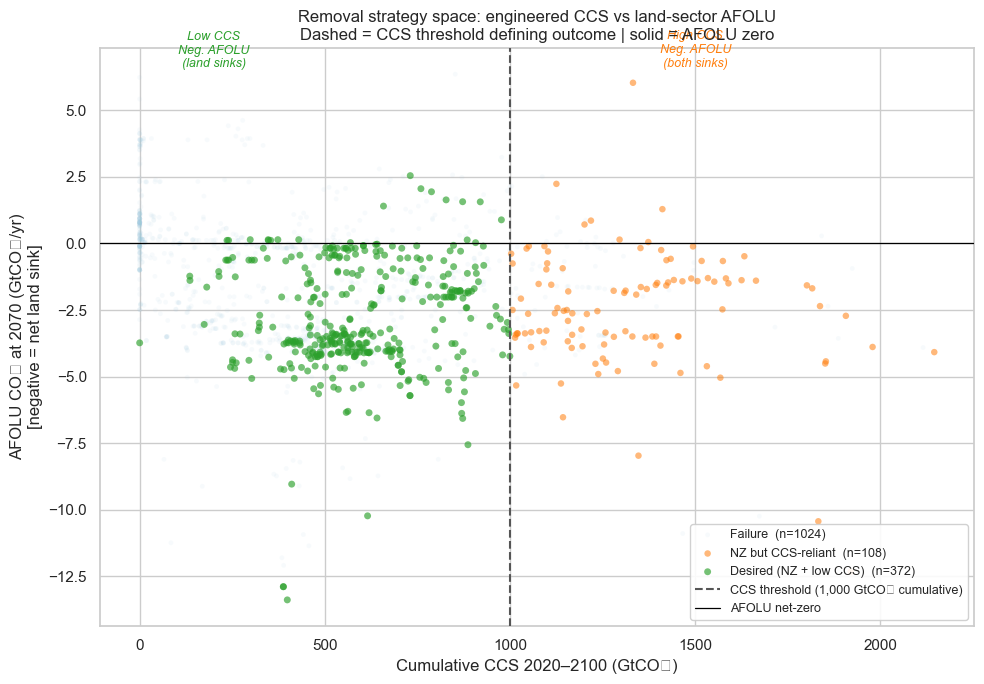

In [2]:
AFOLU_GT_COL = AFOLU_COL_70 + '_Gt'
plot_df = data[[CCS_CUM_COL, AFOLU_GT_COL, 'category']].dropna()

ALPHA = {CAT_FAILURE: 0.08, CAT_HIGHCCS: 0.55, CAT_DESIRED: 0.65}
SIZE  = {CAT_FAILURE: 12,   CAT_HIGHCCS: 22,   CAT_DESIRED: 25}
ZO    = {CAT_FAILURE: 1,    CAT_HIGHCCS: 3,     CAT_DESIRED: 5}

fig, ax = plt.subplots(figsize=(10, 7))

for cat in ORDER:
    sub = plot_df[plot_df['category'] == cat]
    ax.scatter(sub[CCS_CUM_COL], sub[AFOLU_GT_COL],
               color=COLORS[cat], alpha=ALPHA[cat],
               s=SIZE[cat], label=f'{cat}  (n={len(sub)})',
               zorder=ZO[cat], edgecolors='none')

# CCS threshold line (outcome definition)
ax.axvline(1000, color='#555', linewidth=1.5, linestyle='--',
           label='CCS threshold (1,000 GtCO₂ cumulative)', zorder=6)
# AFOLU zero line
ax.axhline(0, color='black', linewidth=0.9, linestyle='-',
           label='AFOLU net-zero', zorder=6)

# Quadrant labels
ax.text(200, ax.get_ylim()[1]*0.9 if ax.get_ylim()[1] > 0 else -2,
        'Low CCS\nNeg. AFOLU\n(land sinks)', fontsize=9, color='#2ca02c',
        ha='center', style='italic')
ax.text(1500, ax.get_ylim()[1]*0.9 if ax.get_ylim()[1] > 0 else -2,
        'High CCS\nNeg. AFOLU\n(both sinks)', fontsize=9, color='#ff7f0e',
        ha='center', style='italic')

ax.set_xlabel('Cumulative CCS 2020–2100 (GtCO₂)')
ax.set_ylabel('AFOLU CO₂ at 2070 (GtCO₂/yr)\n[negative = net land sink]')
ax.set_title('Removal strategy space: engineered CCS vs land-sector AFOLU\n'
             'Dashed = CCS threshold defining outcome | solid = AFOLU zero',
             fontsize=12)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig('afolu_vs_ccs_map.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. AFOLU trajectory by outcome group

C:\Users\rb1624\AppData\Local\Temp\ipykernel_25088\3171048305.py:26: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\rb1624\AppData\Local\Temp\ipykernel_25088\3171048305.py:27: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig('afolu_trajectory.png', dpi=150, bbox_inches='tight')


C:\Users\rb1624\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


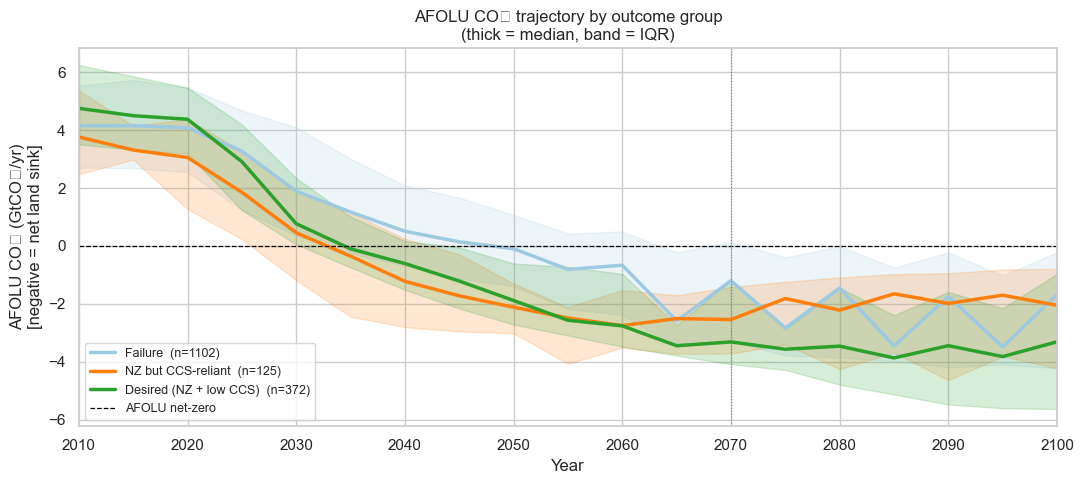

In [3]:
afolu_cols = sorted(
    [c for c in data.columns if c.startswith('Emissions|CO2|AFOLU|') and c.split('|')[-1].isdigit()],
    key=lambda c: int(c.split('|')[-1])
)
years_af = [int(c.split('|')[-1]) for c in afolu_cols]

fig, ax = plt.subplots(figsize=(11, 5))
for cat in ORDER:
    sub = data[data['category'] == cat][afolu_cols]
    col = COLORS[cat]
    n   = len(sub)
    med = sub.median().values / 1e3
    p25 = sub.quantile(0.25).values / 1e3
    p75 = sub.quantile(0.75).values / 1e3
    ax.fill_between(years_af, p25, p75, color=col, alpha=0.18)
    ax.plot(years_af, med, color=col, linewidth=2.5, label=f'{cat}  (n={n})')

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', label='AFOLU net-zero')
ax.axvline(2070, color='gray', linewidth=0.8, linestyle=':')
ax.set_xlim(2010, 2100)
ax.set_xlabel('Year')
ax.set_ylabel('AFOLU CO₂ (GtCO₂/yr)\n[negative = net land sink]')
ax.set_title('AFOLU CO₂ trajectory by outcome group\n'
             '(thick = median, band = IQR)', fontsize=12)
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout()
plt.savefig('afolu_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Is AFOLU a differentiator between desired and CCS-reliant pathways?

Both groups reach net-zero by 2070. If desired-success pathways have MORE negative AFOLU,
it suggests they compensate for limiting CCS with stronger land sinks.

C:\Users\rb1624\AppData\Local\Temp\ipykernel_25088\3016063458.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\rb1624\AppData\Local\Temp\ipykernel_25088\3016063458.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\rb1624\AppData\Local\Temp\ipykernel_25088\3016063458.py:31: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


C:\Users\rb1624\AppData\Local\Temp\ipykernel_25088\3016063458.py:32: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig('afolu_vs_outcome_boxplot.png', dpi=150, bbox_inches='tight')


C:\Users\rb1624\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


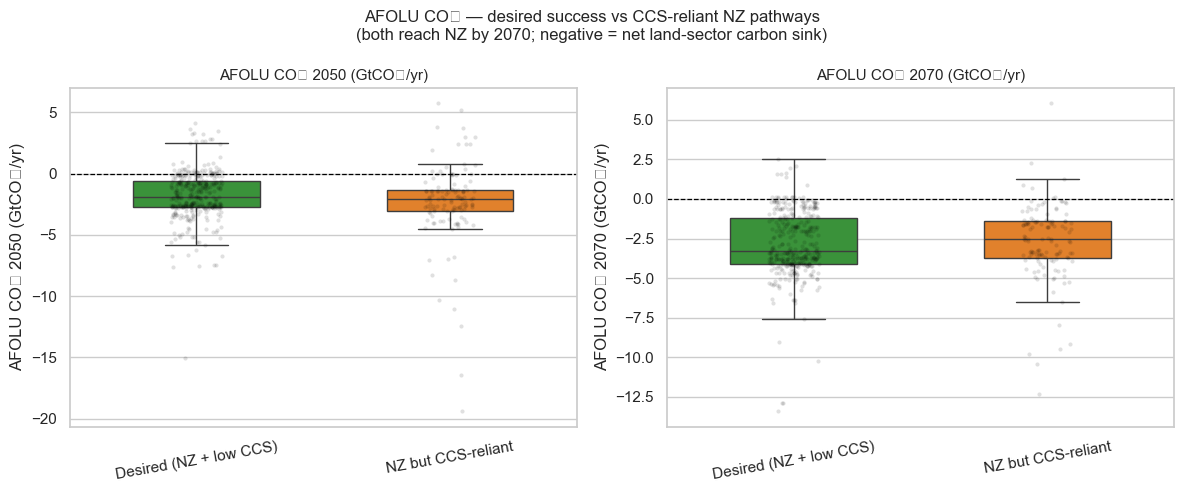

AFOLU 2050: Desired median=-1.88  CCS-reliant median=-2.11  p=0.0337
AFOLU 2070: Desired median=-3.31  CCS-reliant median=-2.54  p=0.2094


In [4]:
nz_groups = [CAT_DESIRED, CAT_HIGHCCS]
nz_df = data[data['category'].isin(nz_groups)].copy()

AFOLU_GT50 = AFOLU_COL_50 + '_Gt'

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (col, xlabel) in zip(axes, [
    (AFOLU_GT50, 'AFOLU CO₂ 2050 (GtCO₂/yr)'),
    (AFOLU_GT_COL, 'AFOLU CO₂ 2070 (GtCO₂/yr)'),
]):
    sub = nz_df[[col, 'category']].dropna()
    sns.boxplot(
        data=sub, x='category', y=col,
        order=nz_groups, palette=COLORS,
        width=0.5, ax=ax, showfliers=False
    )
    sns.stripplot(
        data=sub, x='category', y=col, order=nz_groups,
        color='black', alpha=0.12, size=3, jitter=True, ax=ax
    )
    ax.axhline(0, color='black', linewidth=0.9, linestyle='--')
    ax.set_xlabel('')
    ax.set_ylabel(xlabel)
    ax.set_title(xlabel, fontsize=11)
    plt.setp(ax.get_xticklabels(), rotation=10)

fig.suptitle('AFOLU CO₂ — desired success vs CCS-reliant NZ pathways\n'
             '(both reach NZ by 2070; negative = net land-sector carbon sink)',
             fontsize=12)
plt.tight_layout()
plt.savefig('afolu_vs_outcome_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical test
for col, label in [(AFOLU_GT50, '2050'), (AFOLU_GT_COL, '2070')]:
    a = nz_df.loc[nz_df['category']==CAT_DESIRED,  col].dropna()
    b = nz_df.loc[nz_df['category']==CAT_HIGHCCS,  col].dropna()
    if len(a) >= 5 and len(b) >= 5:
        u, p = stats.mannwhitneyu(a, b, alternative='two-sided')
        print(f'AFOLU {label}: Desired median={a.median():.2f}  CCS-reliant median={b.median():.2f}  p={p:.4f}')

## 4. Summary: three pathways to net-zero

In [5]:
print('=== Three pathways to net-zero CO2 by 2070 ===\n')

for cat in [CAT_DESIRED, CAT_HIGHCCS]:
    sub = data[data['category'] == cat]
    ccs_med = sub[CCS_CUM_COL].median()
    afolu50 = (sub[AFOLU_COL_50 + '_Gt'].median() if AFOLU_COL_50+'_Gt' in sub else np.nan)
    afolu70 = (sub[AFOLU_GT_COL].median() if AFOLU_GT_COL in sub else np.nan)
    fossil50 = sub['Primary Energy|Fossil|2050'].median() if 'Primary Energy|Fossil|2050' in sub else np.nan
    elec50   = sub['Electrification|2050'].median() if 'Electrification|2050' in sub else np.nan
    print(f'{cat}  (n={len(sub)}):')
    print(f'  Cumulative CCS:        {ccs_med:.0f} GtCO2')
    print(f'  AFOLU CO2 at 2050:     {afolu50:.2f} GtCO2/yr')
    print(f'  AFOLU CO2 at 2070:     {afolu70:.2f} GtCO2/yr')
    print(f'  Fossil PE at 2050:     {fossil50:.0f} EJ/yr')
    print(f'  Electrification 2050:  {elec50:.1%}')
    print()

print('Interpretation:')
print('  Desired-success scenarios use ALL three levers more aggressively:')
print('  (1) lower fossil primary energy, (2) deeper electrification,')
print('  (3) comparable or stronger AFOLU land sinks.')
print('  CCS-reliant pathways compensate for less aggressive fossil decline')
print('  and less electrification with engineered carbon removal — a more fragile strategy.')

=== Three pathways to net-zero CO2 by 2070 ===

Desired (NZ + low CCS)  (n=372):
  Cumulative CCS:        572 GtCO2
  AFOLU CO2 at 2050:     -1.88 GtCO2/yr
  AFOLU CO2 at 2070:     -3.31 GtCO2/yr
  Fossil PE at 2050:     188 EJ/yr
  Electrification 2050:  46.2%

NZ but CCS-reliant  (n=125):
  Cumulative CCS:        1302 GtCO2
  AFOLU CO2 at 2050:     -2.11 GtCO2/yr
  AFOLU CO2 at 2070:     -2.54 GtCO2/yr
  Fossil PE at 2050:     316 EJ/yr
  Electrification 2050:  42.9%

Interpretation:
  Desired-success scenarios use ALL three levers more aggressively:
  (1) lower fossil primary energy, (2) deeper electrification,
  (3) comparable or stronger AFOLU land sinks.
  CCS-reliant pathways compensate for less aggressive fossil decline
  and less electrification with engineered carbon removal — a more fragile strategy.
